In [30]:
# from dask.distributed import Client,LocalCluster
import xarray as xr
# import numpy as np
# import dask
# import glob
import geopandas as gpd
import rioxarray as rio
import shapely
# import os
# os.environ['GDAL_DATA'] = os.environ['CONDA_PREFIX'] + r'/Library/share/gdal'
# os.environ['PROJ_LIB'] = os.environ['CONDA_PREFIX'] + r'/Library/share'

In [25]:
data_dir=r'C://Users/kerrie/Documents/02_LocalData/nclimgrid_monthly/'
shpfile=r'C://Users/kerrie/Documents/02_LocalData/boundaries/MS_bounds.shp'

In [ ]:
# this may require adjustment on other computers

# kerrie laptop client (machine has 32GB RAM and 20 threads)
# nworkers=20  # set equal to number of threads you have

# kerrie desktop client (machine has 64GB RAM and 16 threads)
# nworkers=16  # set equal to number of threads you have

# cluster=LocalCluster(n_workers=nworkers,threads_per_worker=1)
# client=Client(cluster) 
# client

## Data Cleaning

1) drop any variables we don't need
2) dim names are time, lat, lon
3) time is correct datetimes
4) lat is ascending
5) lon is ascending -180 to 180
6) variable names tmax,tmin,prcp
7) units of C for temperature
8) units of mm/day for precip
9) spatial subset
11) round all values to 2 decimal places
12) save data with smallest possible precision
13) write cleaned files, 1 file per variable


In [99]:
# lazy dataset, all 800+ files
ds=xr.open_dataset(data_dir+'nclimgrid_tmax.nc').sel(time=slice('1964','2023'))

ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 720, lat: 596, lon: 1385)
Coordinates:
  * time     (time) datetime64[ns] 6kB 1964-01-01 1964-02-01 ... 2023-12-01
  * lat      (lat) float32 2kB 49.35 49.31 49.27 49.23 ... 24.65 24.6 24.56
  * lon      (lon) float32 6kB -124.7 -124.6 -124.6 ... -67.1 -67.06 -67.02
Data variables:
    tmax     (time, lat, lon) float32 2GB ...
Attributes: (12/14)
    date_created:              2024-01-05 10:40:47.313624
    date_modified:             2024-01-05 10:40:47.313780
    Conventions:               CF-1.6, ACDD-1.3
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    title:                     nClimGrid
    naming_authority:          gov.noaa.ncei
    ...                        ...
    geospatial_lat_min:        24.562532
    geospatial_lat_max:        49.3542
    geospatial_lon_min:        -124.6875
    geospatial_lon_max:        -67.020836
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east

In [100]:
# step 9 spatial subset
# clip data to a bounding box

# get clip object
clipobj=gpd.read_file(shpfile)
clipobj.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [101]:
# assign crs to netcdf data
ds.rio.write_crs("epsg:4326",inplace=True)
ds_clip=ds.rio.clip(clipobj.geometry.apply(shapely.geometry.mapping),clipobj.crs,drop=True,invert=False)

In [102]:
ds_clip['tmax'] = ds_clip.tmax.round(decimals=2)
ds_clip

<xarray.Dataset> Size: 28MB
Dimensions:      (time: 720, lat: 116, lon: 85)
Coordinates:
  * time         (time) datetime64[ns] 6kB 1964-01-01 1964-02-01 ... 2023-12-01
  * lat          (lat) float32 464B 34.98 34.94 34.9 34.85 ... 30.27 30.23 30.19
  * lon          (lon) float32 340B -91.6 -91.56 -91.52 ... -88.19 -88.15 -88.1
    spatial_ref  int32 4B 0
Data variables:
    tmax         (time, lat, lon) float32 28MB nan nan nan nan ... nan nan nan
Attributes: (12/14)
    date_created:              2024-01-05 10:40:47.313624
    date_modified:             2024-01-05 10:40:47.313780
    Conventions:               CF-1.6, ACDD-1.3
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    title:                     nClimGrid
    naming_authority:          gov.noaa.ncei
    ...                        ...
    geospatial_lat_min:        24.562532
    geospatial_lat_max:        49.3542
    geospatial_lon_min:        -124.6875
    geospatial_lon_max:        -67.020836
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east

In [51]:
del ds_clip['spatial_ref']
ds_clip

<xarray.Dataset> Size: 14MB
Dimensions:  (time: 360, lat: 116, lon: 85)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1994-01-01 1994-02-01 ... 2023-12-01
  * lat      (lat) float32 464B 34.98 34.94 34.9 34.85 ... 30.27 30.23 30.19
  * lon      (lon) float32 340B -91.6 -91.56 -91.52 ... -88.19 -88.15 -88.1
Data variables:
    tmax     (time, lat, lon) float32 14MB nan nan nan nan ... nan nan nan nan
Attributes: (12/14)
    date_created:              2024-01-05 10:40:47.313624
    date_modified:             2024-01-05 10:40:47.313780
    Conventions:               CF-1.6, ACDD-1.3
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    title:                     nClimGrid
    naming_authority:          gov.noaa.ncei
    ...                        ...
    geospatial_lat_min:        24.562532
    geospatial_lat_max:        49.3542
    geospatial_lon_min:        -124.6875
    geospatial_lon_max:        -67.020836
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east

In [103]:
ds_clip = ds_clip.reindex(lat=ds_clip.lat[::-1])
ds_clip

<xarray.Dataset> Size: 28MB
Dimensions:      (time: 720, lat: 116, lon: 85)
Coordinates:
  * time         (time) datetime64[ns] 6kB 1964-01-01 1964-02-01 ... 2023-12-01
  * lat          (lat) float32 464B 30.19 30.23 30.27 30.31 ... 34.9 34.94 34.98
  * lon          (lon) float32 340B -91.6 -91.56 -91.52 ... -88.19 -88.15 -88.1
    spatial_ref  int32 4B 0
Data variables:
    tmax         (time, lat, lon) float32 28MB nan nan nan nan ... nan nan nan
Attributes: (12/14)
    date_created:              2024-01-05 10:40:47.313624
    date_modified:             2024-01-05 10:40:47.313780
    Conventions:               CF-1.6, ACDD-1.3
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    title:                     nClimGrid
    naming_authority:          gov.noaa.ncei
    ...                        ...
    geospatial_lat_min:        24.562532
    geospatial_lat_max:        49.3542
    geospatial_lon_min:        -124.6875
    geospatial_lon_max:        -67.020836
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east

In [104]:
tmax=ds_clip.tmax.data.astype('float16')
tmax.shape, tmax.nbytes

((720, 116, 85), 14198400)

In [105]:
lat= list(ds_clip.lat.data)
lon= list(ds_clip.lon.data)
time=ds_clip.time.data
# lat

In [106]:
time = time.astype('str')
time = [t[0:7] for t in time]
time[0]

'1964-01'

In [107]:
with open('nclimgrid_tmax_196401-202312.npy','wb') as f:
    np.save(f,tmax)

with open('nclimgrid_tmax_meta_lat.txt','w') as f:
    np.savetxt(f,lat,fmt='%.6f')

with open('nclimgrid_tmax_meta_lon.txt','w') as f:
    np.savetxt(f,lon,fmt='%.6f')

with open('nclimgrid_tmax_meta_time.txt','w') as f:
    np.savetxt(f,time,fmt='%s')

In [108]:
test=np.load('nclimgrid_tmax.npy')
test.shape

(720, 116, 85)

In [109]:
import matplotlib.pyplot as plt

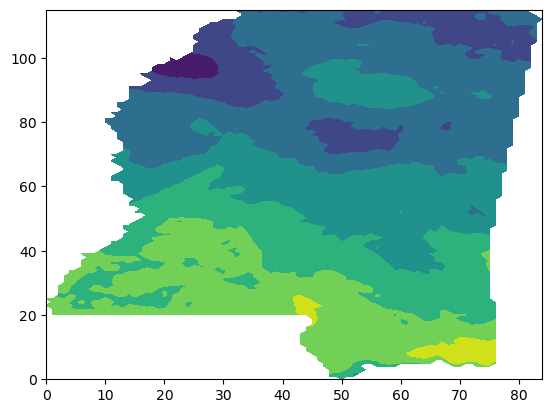

In [115]:
plt.contourf(test[0,:,:])

In [53]:
# ds_clip.tmax.to_netcdf(data_dir+'nclimgrid_tmax_196401-202312.nc')
ds_clip.tmax.to_netcdf(data_dir+'nclimgrid_tmax_199401-202312.nc')

In [63]:
import numpy as np
              # C:\Users\kerrie\Documents\01_LocalCode\repos\DEV_canvas_beginner_py
datafile = r'C://Users/kerrie/Documents/01_LocalCode/repos/DEV_canvas_beginner_py/tmax_data.csv'

In [69]:
# data = np.loadtxt(datafile, delimiter=',', skiprows=1)
data = np.loadtxt('tmax_data.csv', delimiter=',', skiprows=1, usecols=(3), unpack=True)


data

ValueError: could not convert string '' to float64 at row 0, column 4.

In [ ]:
# 1) drop data we don't need"
ds = ds.drop_vars('tavg')

steps 2-7 aren't necessary, data already looks good wrt to these items

In [ ]:
# step 8 millimeter --> mm/day
ds.prcp.attrs['units']='mm/day'

In [ ]:
# step 9 spatial subset
# clip data to a bounding box

# get clip object
box=gpd.read_file(shpfile)

# assign crs to netcdf data
ds.rio.write_crs("epsg:4326",inplace=True)
ds_clip=ds.rio.clip(box.geometry.apply(shapely.geometry.mapping),box.crs,drop=True,invert=False)
ds_clip

In [ ]:
# save metadata separately for later
coords = ds_clip.coords
prcp_attrs = ds_clip.prcp.attrs
tmax_attrs = ds_clip.tmax.attrs
tmin_attrs = ds_clip.tmin.attrs
dims = ds_clip.dims
print(dims)
coords

step 10 & 11, round and reduce precision

In [ ]:
# choosing a single time to test data precision, looking for values on order of at least 100
testtime='2000-06-4'
ds_clip.prcp.sel(time=testtime).plot()

In [ ]:
# float16 is probably not enough precision, let's check on a subset of the data

print('loading float16')
prcp_16 = ds_clip.prcp.sel(time=testtime).astype('float16').load()
print('loading float32')
prcp_32 = ds_clip.prcp.sel(time=testtime).astype('float32').load()
print('loading float64')
prcp_64 = ds_clip.prcp.sel(time=testtime).load()

prcp_16.max().item(),prcp_32.max().item(),prcp_64.max().item()

so we can change the data type from float64 to float32 but not go any smaller

In [ ]:
# steps 10 & 11
ds = ds_clip.round(decimals=2)
ds = ds_clip.astype('float32')
ds

# write files

I think what we have to do to write each chunk to a separate file is:
- chunk xr arrays in space instead of time
- convert to numpy so we can use to_delayed and ravel
- every worker needs the xr metadata for variable and coordinates
- write a dask delayed function that takes the numpy array data and the metadata separately
- inside the dask delayed function re-create the xarray object and write to file

In [ ]:
# create an integer index for the dim we will chunk (longitude)
ilon_ind = np.arange(0,len(ds.lon)).astype('int')
ds.coords['ilon_index']=('lon',ilon_ind)
# ds.ilon_index.attrs['standard_name']='integer_index_longitude'

In [ ]:
# chunking along longitude only
nlons=6
ds = ds.chunk({'time':-1,'lat':-1,'lon':nlons})
ds

In [ ]:
ilon_chunks = xr.DataArray(ds.ilon_index.data,coords={'ilon_index':('lon',ds.ilon_index.data)})#.chunk({'lon':nlons}).data.to_delayed().ravel()
ilon_chunks

In [ ]:
# a function to return a list of data chunks 
# and the corresponding longitude coord chunks
def xr_ds_to_delayed(ds,varname):
    # chunk the appropriate variable in ds, delay, ravel to list
    var_chunks = ds[varname].data.to_delayed().ravel()
    # xarray doesn't allow chunking of coordinates, so we have to make a new variable to chunk
    # the convoluted process is xarray-->numpy-->xarray-->chunk-->numpy-->delay-->ravel
    lon_chunks = xr.DataArray(ds.lon.data,coords={'lon':('lon',ds.lon.data)}).chunk({'lon':nlons}).data.to_delayed().ravel()
    ilon_chunks = xr.DataArray(ds.ilon_index.data,coords={'ilon_index':('lon',ds.ilon_index.data)}).chunk({'lon':nlons}).data.to_delayed().ravel()
    return var_chunks,lon_chunks,ilon_chunks,ds.spatial_ref

# numpy back to xarray, reattaching metadata and writing chunks to separate files
def write_chunk_to_netcdf(datapath,chunk_id,varname,
                          np_datachunk,xr_time,xr_lat,
                          spatial_ref,np_ilonind,np_lonchunk,
                          lon_meta,var_meta):
    
    chunk_id = str(chunk_id).zfill(3)
    # numpy-->xarray
    xr_datachunk = xr.Dataset({varname:(['time','lat','lon'],np_datachunk)},
                              coords={'time':('time',xr_time.data),
                                      'lat':('lat',xr_lat.data),
                                      'lon':('lon',np_lonchunk),
                                      'spatial_ref':('spatial_ref',spatial_ref),
                                      'ilon_index':('lon',np_ilonind)})
    # copy over xr metadata
    xr_datachunk.time.attrs=xr_time.attrs
    xr_datachunk.lat.attrs=xr_lat.attrs
    xr_datachunk.lon.attrs=lon_meta
    xr_datachunk.ilon_index.attrs['standard_name']='integer_index_longitude'
    xr_datachunk[varname].attrs=var_meta
    
    # clean up metadata
    attrslist=['time','lat','lon',varname]
    for att in attrslist:
        if 'valid_min' in xr_datachunk[att].attrs:
            del xr_datachunk[att].attrs['valid_min']
        if 'valid_max' in xr_datachunk[att].attrs:
            del xr_datachunk[att].attrs['valid_max']
        if (att!=varname) and ('comment' in xr_datachunk[att].attrs):
            del xr_datachunk[att].attrs['comment']
        if 'id' in xr_datachunk[att].attrs:
            del xr_datachunk[att].attrs['id']            
    
    # write file
    xr_datachunk.to_netcdf(datapath+'chunkedlon/'+varname+'_nClimGridDaily_USsouth_'+chunk_id+'.nc')
    return chunk_id

In [ ]:
%%time 
var='prcp'
var_chunks,lon_chunks,ilon_chunks,spatial_ref = xr_ds_to_delayed(ds,var)
task_list= [dask.delayed(write_chunk_to_netcdf)(data_dir,id,var,
                                                datachunk,ds.time,ds.lat,
                                                spatial_ref,ilonchunk,lonchunk,
                                                ds.lon.attrs,ds[var].attrs) \
            for id,(datachunk,ilonchunk,lonchunk) in enumerate(zip(var_chunks,ilon_chunks,lon_chunks))]
completed_files = dask.compute(*task_list)
len(completed_files)

In [ ]:
%%time 
var='tmax'
var_chunks,lon_chunks = xr_ds_to_delayed(ds,var)
task_list= [dask.delayed(write_chunk_to_netcdf)(data_dir,id,var,
                                                datachunk,ds.time,ds.lat,
                                                lonchunk,ds.lon.attrs,ds[var].attrs) \
            for id,(datachunk,lonchunk) in enumerate(zip(var_chunks,lon_chunks))]
completed_files = dask.compute(*task_list)
len(completed_files)

In [ ]:
%%time 
var='tmin'
var_chunks,lon_chunks = xr_ds_to_delayed(ds,var)
task_list= [dask.delayed(write_chunk_to_netcdf)(data_dir,id,var,
                                                datachunk,ds.time,ds.lat,
                                                lonchunk,ds.lon.attrs,ds.prcp.attrs) \
            for id,(datachunk,lonchunk) in enumerate(zip(var_chunks,lon_chunks))]
completed_files = dask.compute(*task_list)

In [ ]:
var='prcp'
files = glob.glob(data_dir+var+'_nClimGridDaily_USsouth_*.nc')
test=xr.open_mfdataset(files)
test

In [ ]:
test[var].isel(time=15).plot()

# old code below to write 1 single file per variable

In [ ]:
%%time
filename='prcp_nClimGridDaily_1951-2024_USsouth.nc'
print('writing',filename)
ds.prcp.to_netcdf(data_dir+filename)

In [ ]:
%%time
filename='tmax_nClimGridDaily_1951-2024_USsouth.nc'
print('writing',filename)
ds.tmax.to_netcdf(data_dir+filename)

In [ ]:
%%time
filename='tmin_nClimGridDaily_1951-2024_USsouth.nc'
print('writing',filename)
ds.tmin.to_netcdf(data_dir+filename)

In [ ]:
test=xr.open_mfdataset(data_dir+filename)
test

In [ ]:
client.shutdown()